In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("covid_vaccine_statewise.csv")
df.head()

,Updated On,State,Total Doses Administered,First Dose Administered,Second Dose Administered
0,16/01/2021,India,48276.0,48276.0,0.0
1,17/01/2021,India,58604.0,58604.0,0.0
2,18/01/2021,India,99449.0,99449.0,0.0
3,19/01/2021,India,195525.0,195525.0,0.0
4,20/01/2021,India,251280.0,251280.0,0.0


In [4]:
# Check missing values
df.isnull().sum()

Updated On                    0
State                         0
Total Doses Administered    335
First Dose Administered     336
Second Dose Administered    336
dtype: int64

In [5]:
# Fill missing values
df.fillna(0, inplace=True)


,Updated On,State,Total Doses Administered,First Dose Administered,Second Dose Administered
0,16/01/2021,India,48276.0,48276.0,0.0
1,17/01/2021,India,58604.0,58604.0,0.0
2,18/01/2021,India,99449.0,99449.0,0.0
3,19/01/2021,India,195525.0,195525.0,0.0
4,20/01/2021,India,251280.0,251280.0,0.0
...,...,...,...,...,...
6694,11/7/2021,West Bengal,0.0,0.0,0.0
6695,12/7/2021,West Bengal,0.0,0.0,0.0
6696,13/07/2021,West Bengal,0.0,0.0,0.0
6697,14/07/2021,West Bengal,0.0,0.0,0.0


In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [7]:
# Convert date column
df['Updated On'] = pd.to_datetime(df['Updated On'], dayfirst=True)

In [8]:
df.describe()

,Updated On,Total Doses Administered,First Dose Administered,Second Dose Administered
count,6699,6.699000e+03,6.699000e+03,6.699000e+03
mean,2021-04-16 00:39:20.232870,6.092597e+06,4.990620e+06,1.101976e+06
min,2021-01-16 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2021-03-02 00:00:00,6.726150e+04,5.901300e+04,2.267000e+03
50%,2021-04-16 00:00:00,4.603120e+05,3.974500e+05,7.033600e+04
75%,2021-05-31 00:00:00,4.456863e+06,3.766212e+06,6.817615e+05
max,2021-07-17 00:00:00,3.561929e+08,2.901329e+08,6.606008e+07
std,NaN,2.553454e+07,2.081550e+07,4.765062e+06


In [9]:
state_first = df.groupby('State')['First Dose Administered'].max()
state_second = df.groupby('State')['Second Dose Administered'].max()

state_first.sort_values(ascending=False).head()

State
India            290132865.0
Uttar Pradesh     29305008.0
Maharashtra       27659911.0
Rajasthan         21454435.0
Gujarat           21181190.0
Name: First Dose Administered, dtype: float64

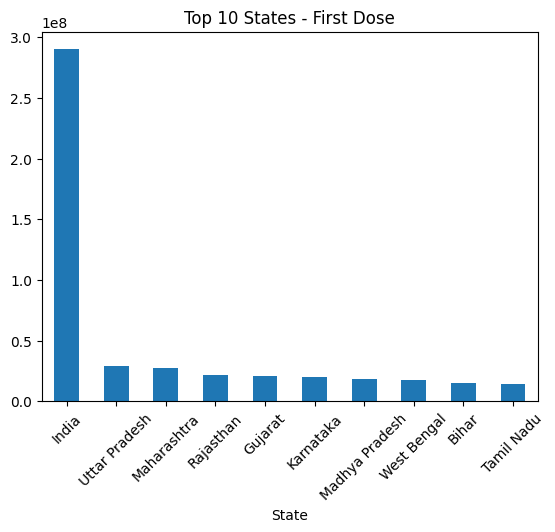

In [10]:
import matplotlib.pyplot as plt

# Top states first dose
state_first.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States - First Dose")
plt.xticks(rotation=45)
plt.show()

In [11]:
print("Top state (First Dose):", state_first.idxmax())

Top state (First Dose): India


In [12]:
print("Top state (First Dose):", state_first.idxmax())
print("Top state (Second Dose):", state_second.idxmax())

Top state (First Dose): India
Top state (Second Dose): India


In [16]:
#male = df['Male (Doses Administered)'].sum()
female = df['Female (Doses Administered)'].sum()

#print("Total Male Vaccinated:", male)
print("Total Female Vaccinated:", female)

if male > female:
    print("More males vaccinated")
else:
    print("More females vaccinated")

KeyError: 'Female (Doses Administered)'

In [14]:
print(df.columns)

Index(['Updated On', 'State', 'Total Doses Administered',
       'First Dose Administered', 'Second Dose Administered'],
      dtype='str')


In [17]:
# Top states by total vaccination
total_state = df.groupby('State')['Total Doses Administered'].max()

print("Top State (Total):", total_state.idxmax())

Top State (Total): India


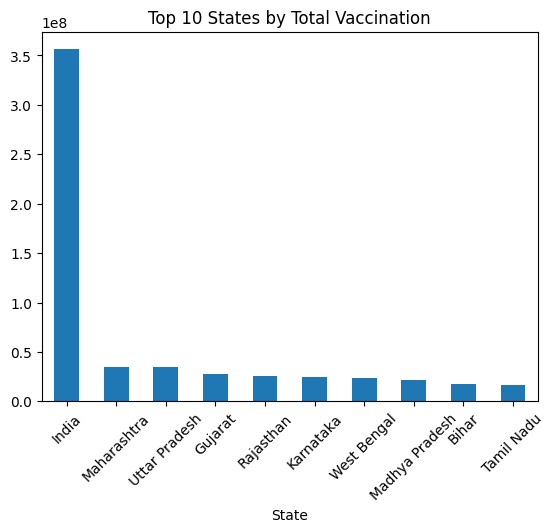

In [18]:
total_state.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States by Total Vaccination")
plt.xticks(rotation=45)
plt.show()

In [19]:
# Gender graph
import matplotlib.pyplot as plt

plt.bar(['Male', 'Female'], [male, female])
plt.title("Gender-wise Vaccination")
plt.ylabel("Doses")
plt.show()

NameError: name 'male' is not defined

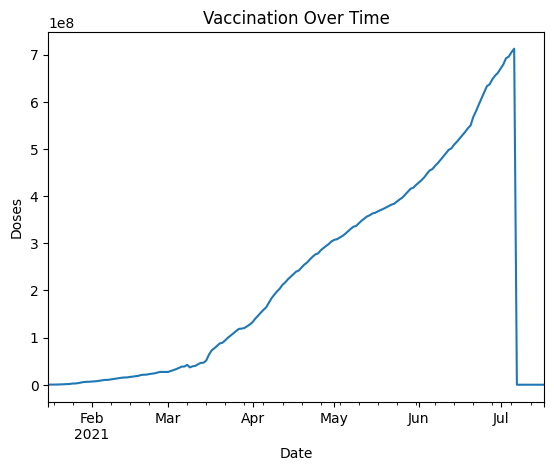

In [20]:
df['Total'] = df['Total Doses Administered']

time_series = df.groupby('Updated On')['Total'].sum()

time_series.plot()
plt.title("Vaccination Over Time")
plt.xlabel("Date")
plt.ylabel("Doses")
plt.show()